<a href="https://colab.research.google.com/github/Ratludu/Backpack-Prediction-Challenge/blob/main/Backpack_Prices_LB_38.84702.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [ ]:
from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('kaggleusername')
os.environ['KAGGLE_KEY'] = userdata.get('kaggleapi')

competition = 'playground-series-s5e2'

!kaggle competitions download -c {competition}

!unzip "{competition}.zip"

 93% 86.0M/92.7M [00:00<00:00, 176MB/s]
100% 92.7M/92.7M [00:00<00:00, 144MB/s]
Archive:  playground-series-s5e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
  inflating: training_extra.csv      


In [85]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("souradippal/student-bag-price-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.23M/1.23M [00:00<00:00, 127MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/souradippal/student-bag-price-prediction-dataset/versions/1


In [ ]:
!pip install dask-cuda==24.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.4/134.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2024.10.0
    Uninstalling dask-2024.10.0:
      Successfully uninstalled dask-2024.10.0


In [ ]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 577, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 577 (delta 116), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (577/577), 188.95 KiB | 1.02 MiB/s, done.
Resolving deltas: 100% (290/290), done.
Installing RAPIDS remaining 24.12.* libraries
Using Python 3.11.11 environment at: /usr
Resolved 154 packages in 1.51s
 Downloaded ucx-py-cu12
 Downloaded cuspatial-cu12
 Downloaded datashader
 Downloaded libcuspatial-cu12
 Downloaded libucx-cu12
 Downloaded cucim-cu12
 Downloaded scikit-image
 Downloaded raft-dask-cu12
 Downloaded cuvs-cu12
 Downloaded cugraph-cu12
 Downloaded cuml-cu12
Prepared 21 packages in 38.67s
Uninstalled 1 package in 82ms
Installed 21 packages in 61ms
 + cucim-cu12==24.12.0
 + cugraph-cu12==24.12.0
 + cuml-cu12==24.12.0
 + cuproj-cu12==24.12.0
 + cuspatial-cu12==24.12.0
 + cuvs-cu12==24.12.0
 + cuxfilter-cu12

In [ ]:
!pip install catboost
!pip install optuna
!pip install scikit-learn
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from numpy import random
from cuml.preprocessing import TargetEncoder
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

In [74]:
class config:
    # data links
    train_link = "train.csv"
    train_ex_link = "training_extra.csv"
    test_link = "test.csv"
    sub_link = "sample_submission.csv"

    # create folds config

    n_splits = 25

    # Ignore Columns

    col_ignore = ["id", "Price"]
    num_cols = ["Weight Capacity (kg)"]
    # target

    submit = True

    target = "Price"

    add_original = False

In [ ]:
def rmse(y_true, y_pred):
    error = 0

    for yt, yp in zip(y_true, y_pred):
        error += (yt - yp) ** 2

    m = np.sqrt(error / len(y_true))

    return m

In [ ]:
def random_columns(columns):

  # Generate random number for how many columns we want to concat
  rand_num = np.random.randint(2,5)

  # choose the columns from the list of columns with no repeats
  rand_cols = []
  for i in range(rand_num):
    col = np.random.choice(columns)
    while col in rand_cols:
      col = np.random.choice(columns)
    rand_cols.append(col)

  # return a list of the columns

  return "-".join(col for col in rand_cols),rand_cols


In [88]:
train = pd.read_csv(config.train_link)
train_ex = pd.read_csv(config.train_ex_link)
test = pd.read_csv(config.test_link)
original = pd.read_csv(path+"/Noisy_Student_Bag_Price_Prediction_Dataset.csv")
original.dropna(inplace = True)

In [89]:
train = pd.concat([train,train_ex, original], axis = 0, ignore_index = True)

In [54]:
#train = train.sample(frac = 0.3, random_state = 42, ignore_index = True)

In [90]:
kf = KFold(n_splits = config.n_splits, shuffle = True, random_state = 42)

drop = ['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment', 'Color', 'Waterproof']
added_fe = ['size-laptop compartment_fe','Color-waterproof_fe','weightcapacity-color_fe']
oof = np.zeros(len(train))
preds = np.zeros(len(test))
features = [col for col in train.columns if col not in config.col_ignore]
cats = [col for col in features if col not in config.num_cols]
cats.extend(added_fe)
m = []
for fold, (train_idx, test_idx) in enumerate(kf.split(train)):

    x_train, x_val = train.loc[train_idx, features].copy(), train.loc[test_idx, features].copy()
    y_train, y_val = train.loc[train_idx, config.target].copy(), train.loc[test_idx, config.target].copy()
    x_test = test[features].copy()

    TE = TargetEncoder(n_folds=27, smooth=21, split_method = 'random', stat = 'mean')


    # adding extra features

    x_train["size-laptop compartment_fe"] = x_train['Size'].astype('str')+x_train['Laptop Compartment'].astype('str')
    x_val["size-laptop compartment_fe"] = x_val['Size'].astype('str')+x_val['Laptop Compartment'].astype('str')
    x_test["size-laptop compartment_fe"] = x_test['Size'].astype('str')+x_test['Laptop Compartment'].astype('str')

    x_train["Color-waterproof_fe"] = x_train['Color'].astype('str')+x_train['Waterproof'].astype('str')
    x_val["Color-waterproof_fe"] = x_val['Color'].astype('str')+x_val['Waterproof'].astype('str')
    x_test["Color-waterproof_fe"] = x_test['Color'].astype('str')+x_test['Waterproof'].astype('str')

    x_train["weightcapacity-color_fe"] = x_train['Weight Capacity (kg)'].astype('str') + x_train['Color'].astype('str')
    x_val["weightcapacity-color_fe"] = x_val['Weight Capacity (kg)'].astype('str') + x_val['Color'].astype('str')
    x_test["weightcapacity-color_fe"] = x_test['Weight Capacity (kg)'].astype('str')+x_test['Color'].astype('str')

    x_train["weight_log"] = np.log1p(x_train["Weight Capacity (kg)"])**2
    x_val["weight_log"] = np.log1p(x_val["Weight Capacity (kg)"])**2
    x_test["weight_log"] = np.log1p(x_test["Weight Capacity (kg)"])**2

    for col in added_fe:
      TE.fit(x_train[col], y_train)
      x_train[f'{col}_TE'] = TE.transform(x_train[col])
      x_val[f'{col}_TE'] = TE.transform(x_val[col])
      x_test[f'{col}_TE'] = TE.transform(x_test[col])

    for col in features:
        TE.fit(x_train[col], y_train)
        x_train[f'{col}_TE'] = TE.transform(x_train[col])
        x_val[f'{col}_TE'] = TE.transform(x_val[col])
        x_test[f'{col}_TE'] = TE.transform(x_test[col])

    x_train["colorxweight"] = x_train['Color_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["colorxweight"] = x_val['Color_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["colorxweight"] = x_test['Color_TE']*x_test['Weight Capacity (kg)_TE']

    x_train["Sizexweight"] = x_train['Size_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["Sizexweight"] = x_val['Size_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["Sizexweight"] = x_test['Size_TE']*x_test['Weight Capacity (kg)_TE']

    x_train["Sizexbrand"] = x_train['Size_TE']*x_train['Brand_TE']
    x_val["Sizexbrand"] = x_val['Size_TE']*x_val['Brand_TE']
    x_test["Sizexbrand"] = x_test['Size_TE']*x_test['Brand_TE']

    x_train["Materialxweight"] = x_train['Material_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["Materialxweight"] = x_val['Material_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["Materialxweight"] = x_test['Material_TE']*x_test['Weight Capacity (kg)_TE']

    x_train['Material_TE-Color_TE'] = x_train['Material_TE']*x_train['Color_TE']
    x_val['Material_TE-Color_TE'] = x_val['Material_TE']*x_val['Color_TE']
    x_test['Material_TE-Color_TE'] = x_test['Material_TE']*x_test['Color_TE']

    x_train['Sizexbrand-Materialxweight'] = (x_train['Sizexbrand']-x_train['Materialxweight'])**2
    x_val['Sizexbrand-Materialxweight'] = (x_val['Sizexbrand']-x_val['Materialxweight'])**2
    x_test['Sizexbrand-Materialxweight'] = (x_test['Sizexbrand']-x_test['Materialxweight'])**2

    for cat in cats:
        x_train[cat] =  x_train[cat].fillna("MISSING")
        x_val[cat] = x_val[cat].fillna("MISSING")
        x_test[cat] = x_test[cat].fillna("MISSING")
        x_train[cat] =  x_train[cat].astype('str')
        x_val[cat] = x_val[cat].astype('str')
        x_test[cat] = x_test[cat].astype('str')

    print(x_train.columns)

    model = CatBoostRegressor(
                              learning_rate = 0.11509572776170199,
                              #l2_leaf_reg=5,
                              iterations = 2000,
                              task_type = "GPU",
                              grow_policy = 'Lossguide',
                              random_state = 42,
                              cat_features = cats,
                              verbose = 250,
                              loss_function='RMSE')

    model.fit(x_train, y_train, eval_set=(x_val,y_val))

    val_preds = model.predict(x_val)

    oof[test_idx] = val_preds

    preds += model.predict(x_test)/config.n_splits

    score = rmse(y_val, val_preds)

    m.append(score)

    print(f'Fold: {fold+1}, Score: {score}')

print(f"The average CV is {np.average(m)}")

Index(['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)',
       'size-laptop compartment_fe', 'Color-waterproof_fe',
       'weightcapacity-color_fe', 'weight_log',
       'size-laptop compartment_fe_TE', 'Color-waterproof_fe_TE',
       'weightcapacity-color_fe_TE', 'Brand_TE', 'Material_TE', 'Size_TE',
       'Compartments_TE', 'Laptop Compartment_TE', 'Waterproof_TE', 'Style_TE',
       'Color_TE', 'Weight Capacity (kg)_TE', 'colorxweight', 'Sizexweight',
       'Sizexbrand', 'Materialxweight', 'Material_TE-Color_TE',
       'Sizexbrand-Materialxweight'],
      dtype='object')
0:	learn: 38.8853123	total: 38.7ms	remaining: 1m 17s
250:	learn: 38.6157623	total: 7.73s	remaining: 53.9s
500:	learn: 38.5875303	total: 14.7s	remaining: 43.8s
750:	learn: 38.5624332	total: 21.3s	remaining: 35.5s
1000:	learn: 38.5386038	total: 28s	remaining: 28s
1250:	learn: 38.5165501	total: 34.5s	remaining: 20.7s
1500:	learn: 38.4

In [71]:
save_score = {}
columns = ['size-laptop compartment_fe_TE', 'Color-waterproof_fe_TE',
       'weightcapacity-color_fe_TE', 'Brand_TE', 'Material_TE', 'Size_TE',
       'Compartments_TE', 'Laptop Compartment_TE', 'Waterproof_TE', 'Style_TE',
       'Color_TE', 'Weight Capacity (kg)_TE', 'colorxweight', 'Sizexweight',
       'Sizexbrand', 'Materialxweight']

for trial in range(15):
  print(f"Trial: {trial+1}")

  rand_col1 = np.random.choice(columns)
  rand_col2 = np.random.choice(columns)
  name = rand_col1+"-"+rand_col2

  print(name)


  kf = KFold(n_splits = config.n_splits, shuffle = True, random_state = 42)

  drop = ['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment', 'Color', 'Waterproof']
  added_fe = ['size-laptop compartment_fe','Color-waterproof_fe','weightcapacity-color_fe']
  oof = np.zeros(len(train))
  preds = np.zeros(len(test))
  features = [col for col in train.columns if col not in config.col_ignore]
  cats = [col for col in features if col not in config.num_cols]
  cats.extend(added_fe)
  m = []
  for fold, (train_idx, test_idx) in enumerate(kf.split(train)):

      x_train, x_val = train.loc[train_idx, features].copy(), train.loc[test_idx, features].copy()
      y_train, y_val = train.loc[train_idx, config.target].copy(), train.loc[test_idx, config.target].copy()
      x_test = test[features].copy()

      TE = TargetEncoder(n_folds=27, smooth=21, split_method = 'random', stat = 'mean')


      # adding extra features

      x_train["size-laptop compartment_fe"] = x_train['Size'].astype('str')+x_train['Laptop Compartment'].astype('str')
      x_val["size-laptop compartment_fe"] = x_val['Size'].astype('str')+x_val['Laptop Compartment'].astype('str')
      x_test["size-laptop compartment_fe"] = x_test['Size'].astype('str')+x_test['Laptop Compartment'].astype('str')

      x_train["Color-waterproof_fe"] = x_train['Color'].astype('str')+x_train['Waterproof'].astype('str')
      x_val["Color-waterproof_fe"] = x_val['Color'].astype('str')+x_val['Waterproof'].astype('str')
      x_test["Color-waterproof_fe"] = x_test['Color'].astype('str')+x_test['Waterproof'].astype('str')

      x_train["weightcapacity-color_fe"] = x_train['Weight Capacity (kg)'].astype('str') + x_train['Color'].astype('str')
      x_val["weightcapacity-color_fe"] = x_val['Weight Capacity (kg)'].astype('str') + x_val['Color'].astype('str')
      x_test["weightcapacity-color_fe"] = x_test['Weight Capacity (kg)'].astype('str')+x_test['Color'].astype('str')

      x_train["weight_log"] = np.log1p(x_train["Weight Capacity (kg)"])**2
      x_val["weight_log"] = np.log1p(x_val["Weight Capacity (kg)"])**2
      x_test["weight_log"] = np.log1p(x_test["Weight Capacity (kg)"])**2

      for col in added_fe:
        TE.fit(x_train[col], y_train)
        x_train[f'{col}_TE'] = TE.transform(x_train[col])
        x_val[f'{col}_TE'] = TE.transform(x_val[col])
        x_test[f'{col}_TE'] = TE.transform(x_test[col])

      for col in features:
          TE.fit(x_train[col], y_train)
          x_train[f'{col}_TE'] = TE.transform(x_train[col])
          x_val[f'{col}_TE'] = TE.transform(x_val[col])
          x_test[f'{col}_TE'] = TE.transform(x_test[col])

      x_train["colorxweight"] = x_train['Color_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["colorxweight"] = x_val['Color_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["colorxweight"] = x_test['Color_TE']*x_test['Weight Capacity (kg)_TE']

      x_train["Sizexweight"] = x_train['Size_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["Sizexweight"] = x_val['Size_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["Sizexweight"] = x_test['Size_TE']*x_test['Weight Capacity (kg)_TE']

      x_train["Sizexbrand"] = x_train['Size_TE']*x_train['Brand_TE']
      x_val["Sizexbrand"] = x_val['Size_TE']*x_val['Brand_TE']
      x_test["Sizexbrand"] = x_test['Size_TE']*x_test['Brand_TE']

      x_train["Materialxweight"] = x_train['Material_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["Materialxweight"] = x_val['Material_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["Materialxweight"] = x_test['Material_TE']*x_test['Weight Capacity (kg)_TE']

      x_train['Material_TE-Color_TE'] = x_train['Material_TE']*x_train['Color_TE']
      x_val['Material_TE-Color_TE'] = x_val['Material_TE']*x_val['Color_TE']
      x_test['Material_TE-Color_TE'] = x_test['Material_TE']*x_test['Color_TE']

      x_train['Sizexbrand-Materialxweight'] = (x_train['Sizexbrand']-x_train['Materialxweight'])**2
      x_val['Sizexbrand-Materialxweight'] = (x_val['Sizexbrand']-x_val['Materialxweight'])**2
      x_test['Sizexbrand-Materialxweight'] = (x_test['Sizexbrand']-x_test['Materialxweight'])**2

      for cat in cats:
          x_train[cat] =  x_train[cat].fillna("MISSING")
          x_val[cat] = x_val[cat].fillna("MISSING")
          x_test[cat] = x_test[cat].fillna("MISSING")
          x_train[cat] =  x_train[cat].astype('str')
          x_val[cat] = x_val[cat].astype('str')
          x_test[cat] = x_test[cat].astype('str')

      x_train[name] = (x_train[rand_col1]-x_train[rand_col2])**2
      x_val[name] = (x_val[rand_col1]-x_val[rand_col2])**2
      x_test[name] = (x_test[rand_col1]-x_test[rand_col2])**2

      print(x_train.columns)

      model = CatBoostRegressor(
                                learning_rate = 0.11509572776170199,
                                #l2_leaf_reg=5,
                                iterations = 2000,
                                task_type = "GPU",
                                grow_policy = 'Lossguide',
                                random_state = 42,
                                cat_features = cats,
                                verbose = 250,
                                loss_function='RMSE')

      model.fit(x_train, y_train, eval_set=(x_val,y_val))

      val_preds = model.predict(x_val)

      oof[test_idx] = val_preds

      preds += model.predict(x_test)/config.n_splits

      score = rmse(y_val, val_preds)

      m.append(score)

      print(f'Fold: {fold+1}, Score: {score}')

  print(f"The average CV is {np.average(m)}")
  save_score[name] = np.average(m)

Trial: 1
Sizexbrand-Compartments_TE
Index(['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)',
       'size-laptop compartment_fe', 'Color-waterproof_fe',
       'weightcapacity-color_fe', 'weight_log',
       'size-laptop compartment_fe_TE', 'Color-waterproof_fe_TE',
       'weightcapacity-color_fe_TE', 'Brand_TE', 'Material_TE', 'Size_TE',
       'Compartments_TE', 'Laptop Compartment_TE', 'Waterproof_TE', 'Style_TE',
       'Color_TE', 'Weight Capacity (kg)_TE', 'colorxweight', 'Sizexweight',
       'Sizexbrand', 'Materialxweight', 'Material_TE-Color_TE',
       'Sizexbrand-Materialxweight', 'Sizexbrand-Compartments_TE'],
      dtype='object')
0:	learn: 38.8751239	test: 38.9018087	best: 38.9018087 (0)	total: 11ms	remaining: 22s
250:	learn: 38.6058110	test: 38.7817384	best: 38.7801229 (134)	total: 2.14s	remaining: 14.9s
500:	learn: 38.4889803	test: 38.7841966	best: 38.7801229 (134)	total: 4.25s	remaining: 1

In [72]:
save_score

{'Sizexbrand-Compartments_TE': 38.76369540157105,
 'Brand_TE-Material_TE': 38.764216925528295,
 'colorxweight-colorxweight': 38.763600197760944,
 'Brand_TE-Materialxweight': 38.76413600598551,
 'Waterproof_TE-Weight Capacity (kg)_TE': 38.76380232822111,
 'colorxweight-Sizexweight': 38.76451823324078,
 'Sizexweight-Brand_TE': 38.76425113899705,
 'Style_TE-colorxweight': 38.76435998776202,
 'Sizexweight-Waterproof_TE': 38.764369127485566,
 'colorxweight-Laptop Compartment_TE': 38.76432720008139,
 'weightcapacity-color_fe_TE-Materialxweight': 38.76397351355763,
 'Style_TE-Color_TE': 38.76429176220967,
 'size-laptop compartment_fe_TE-Color_TE': 38.76492751348231,
 'Sizexweight-Size_TE': 38.76379471924476,
 'Sizexweight-Color-waterproof_fe_TE': 38.76457572610675}

<Axes: >

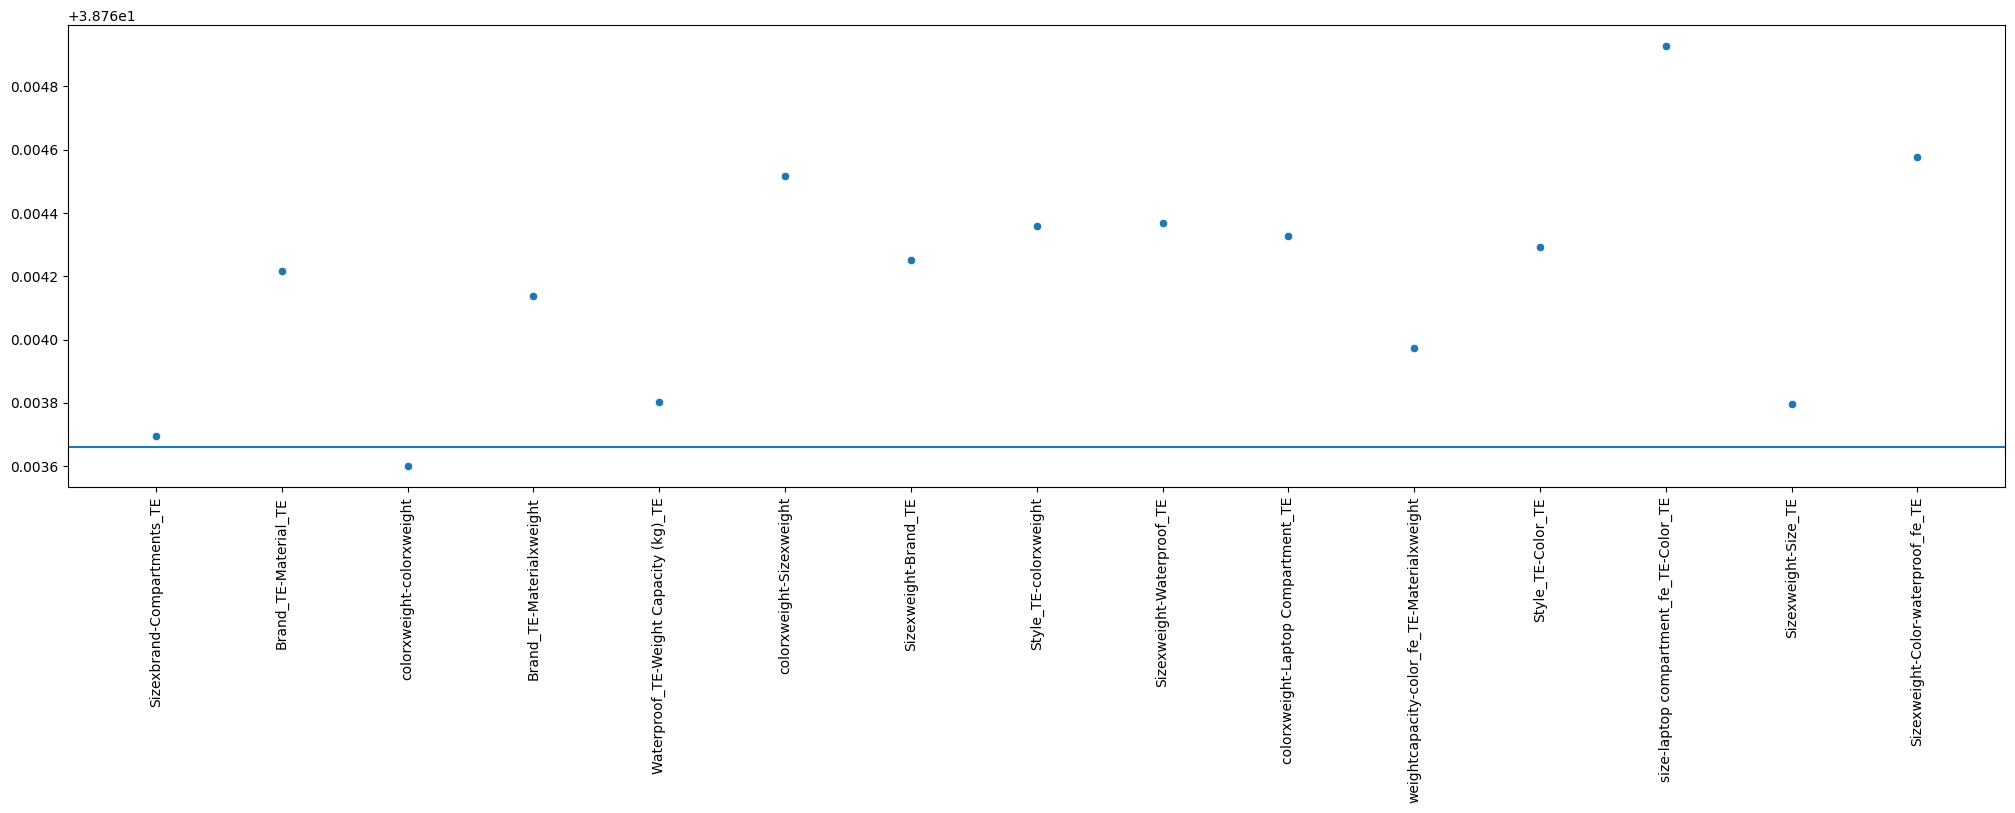

In [73]:
# plot the scores
keys = list(save_score.keys())
values = list(save_score.values())

plt.figure(figsize=(25, 6))
plt.xticks(rotation=90)
plt.axhline(y= 38.76366019542406)
sns.scatterplot(x = keys, y =values)

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(x=model.get_feature_importance(), y=x_train.columns)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [91]:
submission = pd.read_csv(config.sub_link)
submission[config.target] = preds
submission.to_csv("submission.csv", index = False)

submission

,id,Price
0,300000,81.588954
1,300001,82.912121
2,300002,88.672362
3,300003,78.943470
4,300004,79.161465
...,...,...
199995,499995,81.902955
199996,499996,72.366397
199997,499997,83.094103
199998,499998,82.068087


In [92]:
if config.submit:
  !kaggle competitions submit -c {competition} -f submission.csv -m 'Submission with cv 38.65621541449492'

100% 4.74M/4.74M [00:01<00:00, 4.52MB/s]
Successfully submitted to Backpack Prediction Challenge

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
!kaggle competitions submissions -c {competition}